In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the data
file_path = r'D:\Desktop\Final data.xlsx'
df = pd.read_excel(file_path, sheet_name='estbn form (2)')

# Basic data info
print(f"Total rows: {len(df)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Total rows: 219

First 5 rows:
   gender   level  interest academic track                         track  \
0  Female   third                      Low               Web Development   
1    Male   third                      Low  Artificial Intelligence (AI)   
2  Female  second                     High                 data analysis   
3  Female  second                  Neutral                 data analysis   
4    Male  fourth                     High               Web Development   

  Hesitant for choice   factor of choice sufficient resources   \
0             Neutral  Job Market Demand                   Yes   
1   Slightly Hesitant  Job Market Demand                   Yes   
2             Neutral  Job Market Demand                    No   
3             Neutral  Job Market Demand             Partially   
4       Very Hesitant  Job Market Demand                   Yes   

  practical internships  satisfy in college gap from practical  \
0                     No            Neutral      

Gender Distribution:
gender
Male      116
Female    103
Name: count, dtype: int64

Percentage:
gender
Male      52.968037
Female    47.031963
Name: proportion, dtype: float64


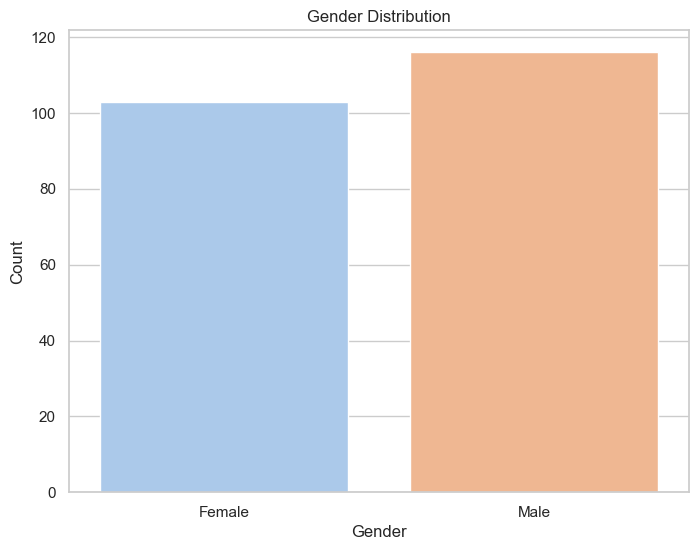


Academic Level Distribution:
level
third     77
fourth    49
first     48
second    45
Name: count, dtype: int64

Percentage:
level
third     35.159817
fourth    22.374429
first     21.917808
second    20.547945
Name: proportion, dtype: float64


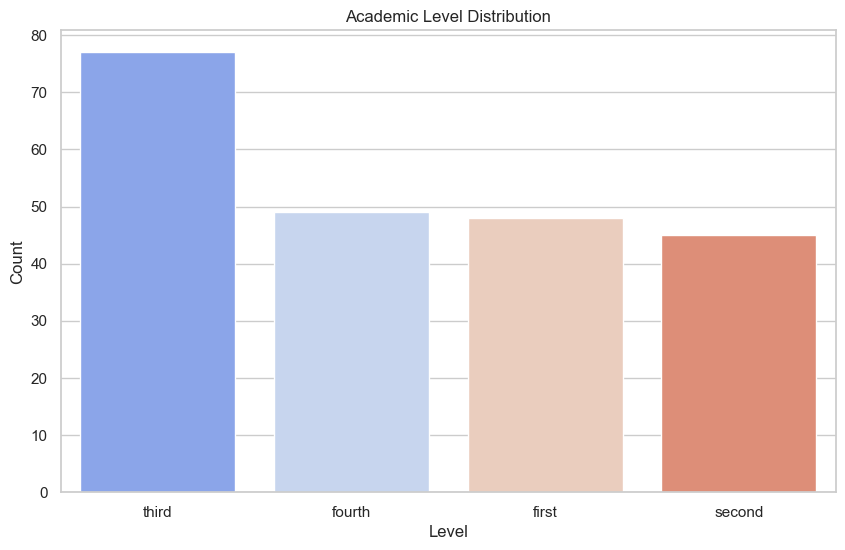


Gender by Level Distribution:
gender  Female  Male
level               
first       16    32
fourth      21    28
second      20    25
third       46    31


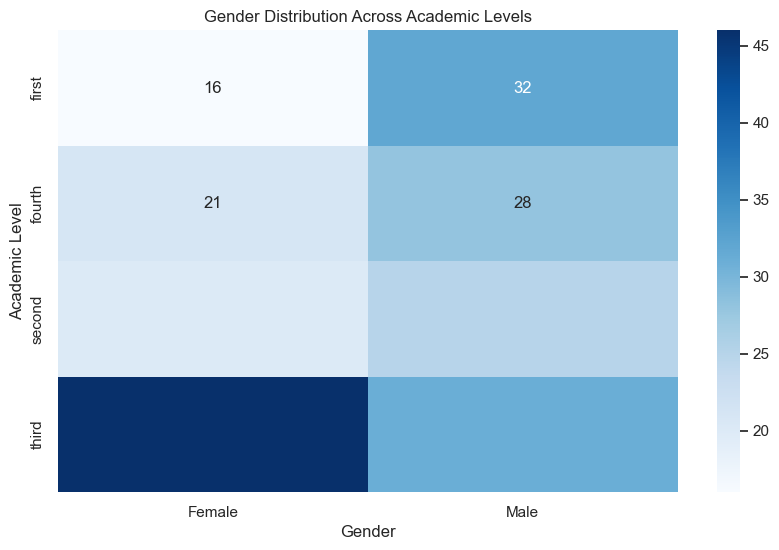

In [2]:
# 1. Gender Distribution
gender_counts = df['gender'].value_counts()
gender_perc = df['gender'].value_counts(normalize=True) * 100

print("Gender Distribution:")
print(gender_counts)
print("\nPercentage:")
print(gender_perc)

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='gender', palette='pastel')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# 2. Academic Level Distribution
level_counts = df['level'].value_counts()
level_perc = df['level'].value_counts(normalize=True) * 100

print("\nAcademic Level Distribution:")
print(level_counts)
print("\nPercentage:")
print(level_perc)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='level', order=df['level'].value_counts().index, palette='coolwarm')
plt.title('Academic Level Distribution')
plt.xlabel('Level')
plt.ylabel('Count')
plt.show()

# 3. Gender by Level Crosstab
gender_level = pd.crosstab(df['level'], df['gender'])
print("\nGender by Level Distribution:")
print(gender_level)

plt.figure(figsize=(10, 6))
sns.heatmap(gender_level, annot=True, fmt='d', cmap='Blues')
plt.title('Gender Distribution Across Academic Levels')
plt.xlabel('Gender')
plt.ylabel('Academic Level')
plt.show()

Career Track Distribution:
track
Data Science                    68
Web Development                 40
data analysis                   28
Software Engineering(others)    26
Artificial Intelligence (AI)    22
Cybersecurity                   20
data engineering                14
System Administration            1
Name: count, dtype: int64

Percentage Distribution:
track
Data Science                    31.1
Web Development                 18.3
data analysis                   12.8
Software Engineering(others)    11.9
Artificial Intelligence (AI)    10.0
Cybersecurity                    9.1
data engineering                 6.4
System Administration            0.5
Name: proportion, dtype: float64


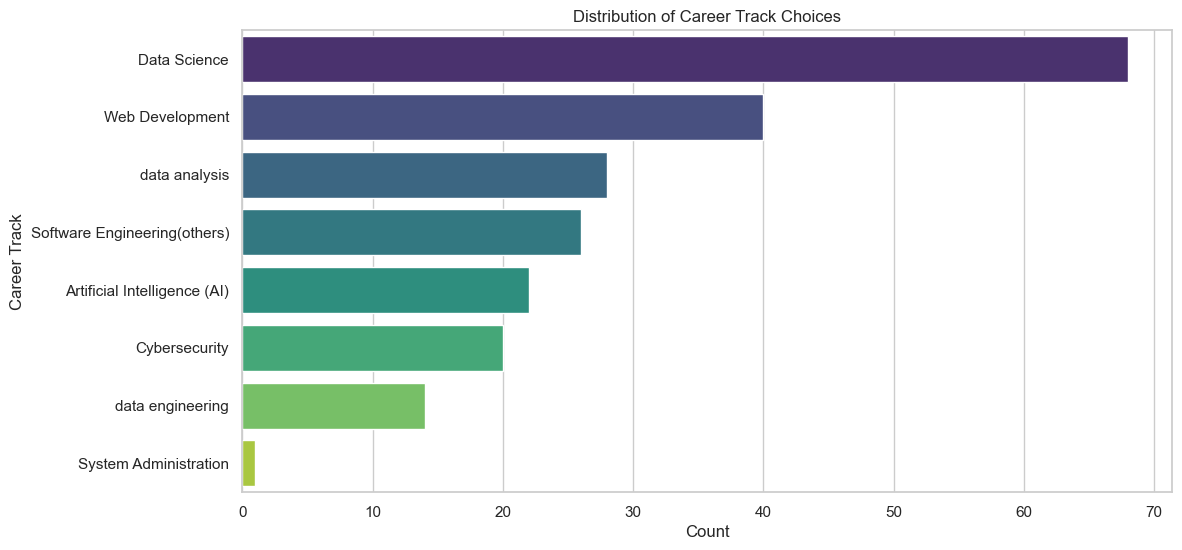


Track Preference by Gender (%):
gender                        Female   Male
track                                      
Artificial Intelligence (AI)    36.4   63.6
Cybersecurity                   55.0   45.0
Data Science                    50.0   50.0
Software Engineering(others)    38.5   61.5
System Administration            0.0  100.0
Web Development                 52.5   47.5
data analysis                   50.0   50.0
data engineering                35.7   64.3


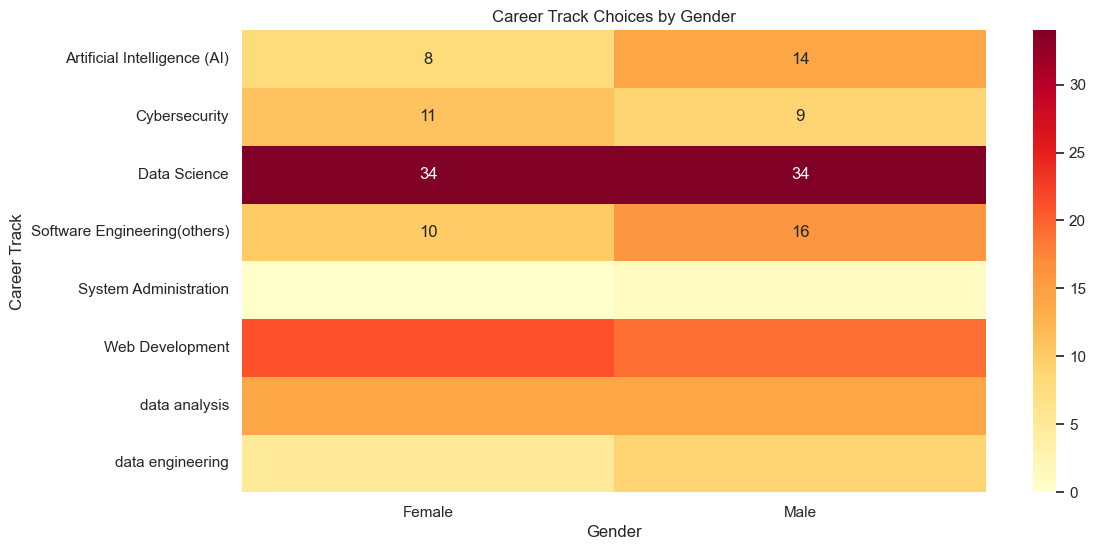


Track Preference by Academic Level:
level                         first  fourth  second  third
track                                                     
Artificial Intelligence (AI)      5       3       4     10
Cybersecurity                     6       4       2      8
Data Science                     17      18      14     19
Software Engineering(others)      6       5       8      7
System Administration             0       0       1      0
Web Development                   6      10       4     20
data analysis                     4       5      10      9
data engineering                  4       4       2      4


In [3]:
# 1. Career Track Distribution
track_counts = df['track'].value_counts()
track_perc = df['track'].value_counts(normalize=True) * 100

print("Career Track Distribution:")
print(track_counts)
print("\nPercentage Distribution:")
print(track_perc.round(1))

# Visualization
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='track', order=df['track'].value_counts().index, palette='viridis')
plt.title('Distribution of Career Track Choices')
plt.xlabel('Count')
plt.ylabel('Career Track')
plt.show()

# 2. Track Preference by Gender
gender_track = pd.crosstab(df['track'], df['gender'])
gender_track_perc = gender_track.div(gender_track.sum(1), axis=0) * 100

print("\nTrack Preference by Gender (%):")
print(gender_track_perc.round(1))

# Visualization
plt.figure(figsize=(12,6))
sns.heatmap(gender_track, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Career Track Choices by Gender')
plt.xlabel('Gender')
plt.ylabel('Career Track')
plt.show()

# 3. Track Preference by Academic Level
level_track = pd.crosstab(df['track'], df['level'])
print("\nTrack Preference by Academic Level:")
print(level_track)

Primary Decision Factors:
factor of choice
Personal Interest    92
Job Market Demand    80
Peer Influence       47
Name: count, dtype: int64

Percentage Distribution:
factor of choice
Personal Interest    42.0
Job Market Demand    36.5
Peer Influence       21.5
Name: proportion, dtype: float64


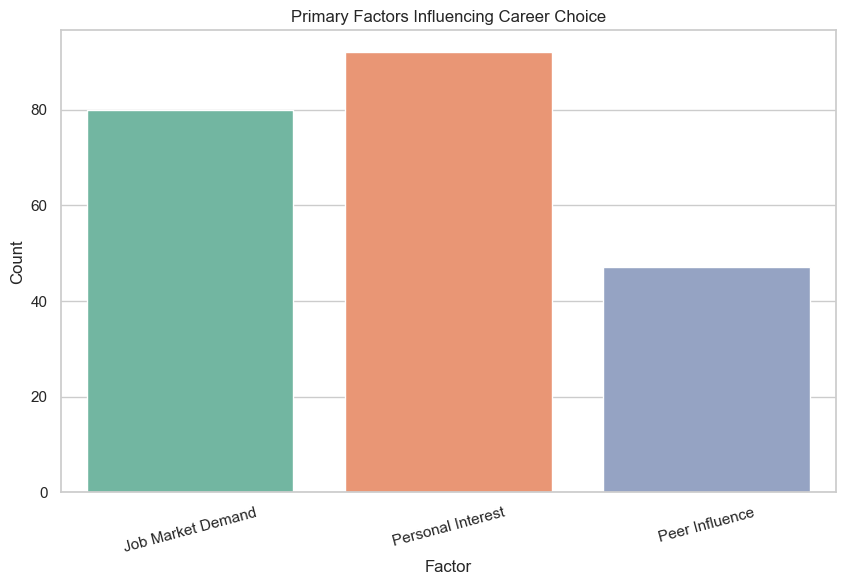


Hesitation Levels:
Hesitant for choice
Very Hesitant        84
Neutral              76
Slightly Hesitant    59
Name: count, dtype: int64

Percentage:
Hesitant for choice
Very Hesitant        38.4
Neutral              34.7
Slightly Hesitant    26.9
Name: proportion, dtype: float64


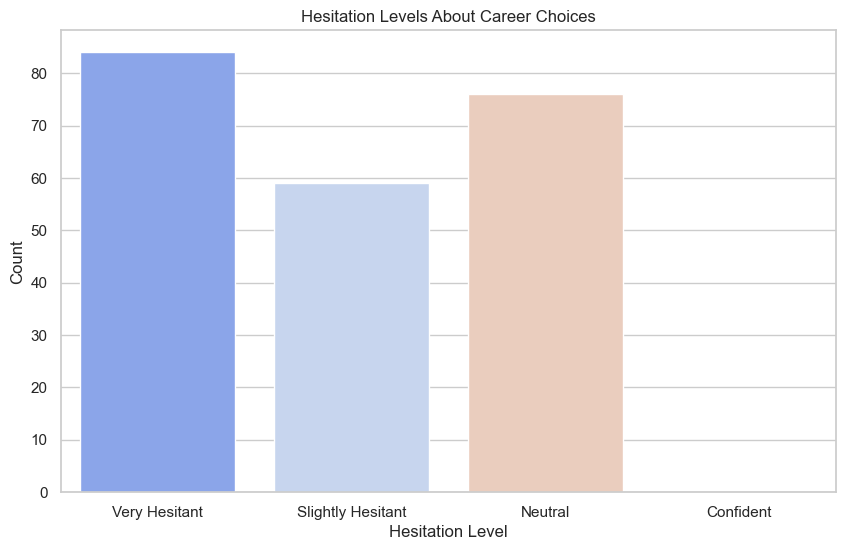

Hesitant for choice,Neutral,Slightly Hesitant,Very Hesitant
factor of choice,,,
Job Market Demand,35.000000,23.750000,41.250000
Peer Influence,38.297872,21.276596,40.425532
Personal Interest,32.608696,32.608696,34.782609


In [4]:
# 1. Primary Decision Factors
decision_factors = df['factor of choice'].value_counts()
decision_perc = df['factor of choice'].value_counts(normalize=True) * 100

print("Primary Decision Factors:")
print(decision_factors)
print("\nPercentage Distribution:")
print(decision_perc.round(1))

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='factor of choice', palette='Set2')
plt.title('Primary Factors Influencing Career Choice')
plt.xlabel('Factor')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

# 2. Hesitation Levels
hesitation_counts = df['Hesitant for choice'].value_counts()
hesitation_perc = df['Hesitant for choice'].value_counts(normalize=True) * 100

print("\nHesitation Levels:")
print(hesitation_counts)
print("\nPercentage:")
print(hesitation_perc.round(1))

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Hesitant for choice', 
              order=['Very Hesitant','Slightly Hesitant','Neutral','Confident'],
              palette='coolwarm')
plt.title('Hesitation Levels About Career Choices')
plt.xlabel('Hesitation Level')
plt.ylabel('Count')
plt.show()

# 3. Decision Factors vs Hesitation
pd.crosstab(df['factor of choice'], df['Hesitant for choice'], normalize='index')*100


Confidence in Achieving Goals:
count    219.000000
mean       3.159817
std        1.396927
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name:  confident  achieving  goals, dtype: float64

Value Counts:
 confident  achieving  goals
1    36
2    38
3    52
4    41
5    52
Name: count, dtype: int64


C:\Users\iTech\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


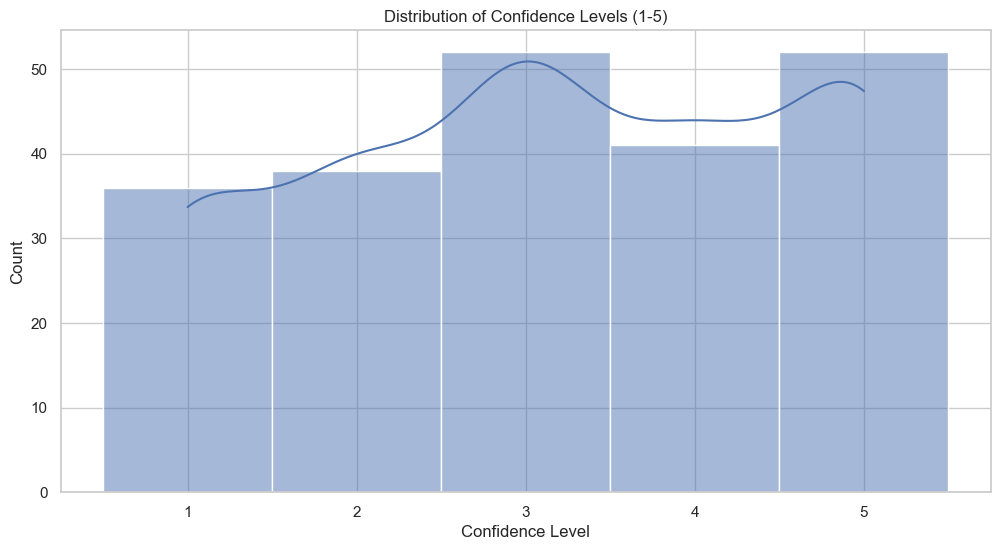


Confidence by Gender:
        count      mean       std  min  25%  50%  75%  max
gender                                                    
Female  103.0  3.165049  1.435523  1.0  2.0  3.0  5.0  5.0
Male    116.0  3.155172  1.367978  1.0  2.0  3.0  4.0  5.0


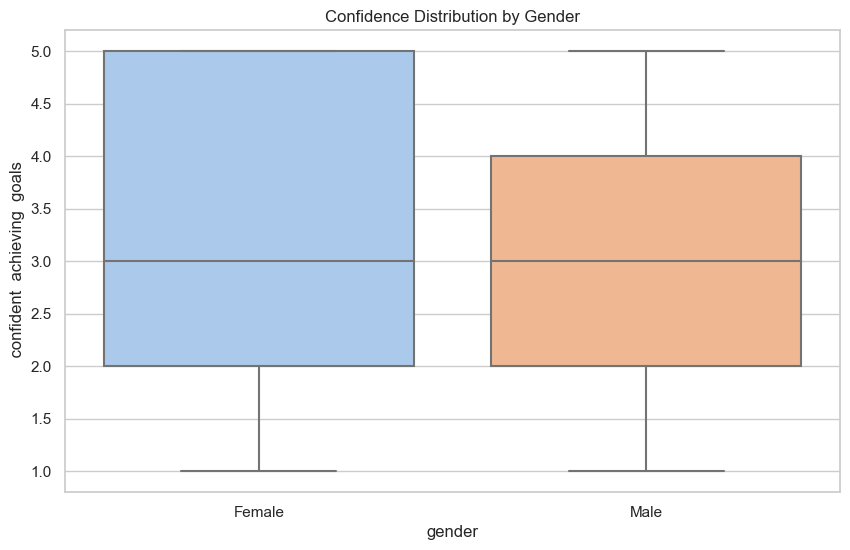


Confidence by Academic Level:
        count      mean       std  min  25%  50%  75%  max
level                                                     
first    48.0  3.250000  1.508839  1.0  2.0  3.0  5.0  5.0
fourth   49.0  3.285714  1.207615  1.0  2.0  3.0  4.0  5.0
second   45.0  3.111111  1.465082  1.0  2.0  3.0  4.0  5.0
third    77.0  3.051948  1.413247  1.0  2.0  3.0  4.0  5.0


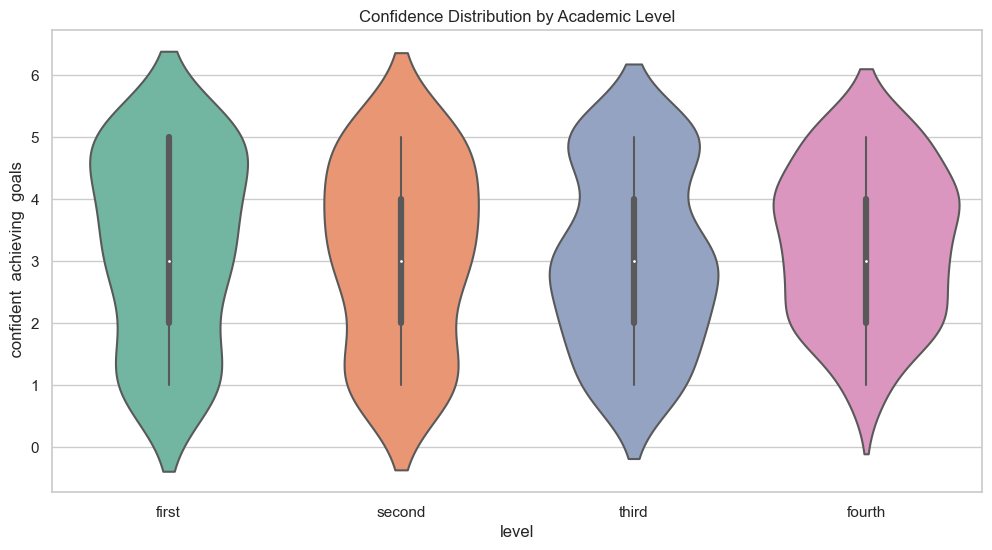

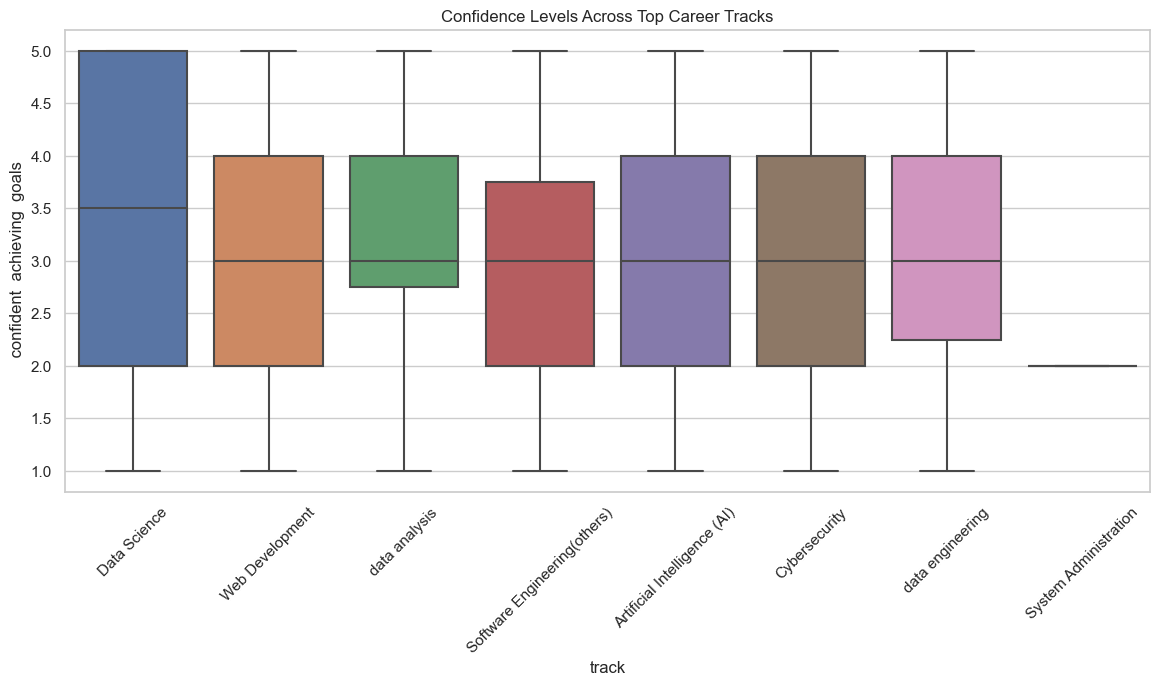


Interview Preparedness Stats:
count    219.00000
mean       2.96347
std        1.41374
min        1.00000
25%        2.00000
50%        3.00000
75%        4.00000
max        5.00000
Name: prepared for interviews, dtype: float64

Correlation between Confidence and Preparedness:
                               confident  achieving  goals  \
 confident  achieving  goals                      1.000000   
prepared for interviews                           0.005292   

                              prepared for interviews  
 confident  achieving  goals                 0.005292  
prepared for interviews                      1.000000  


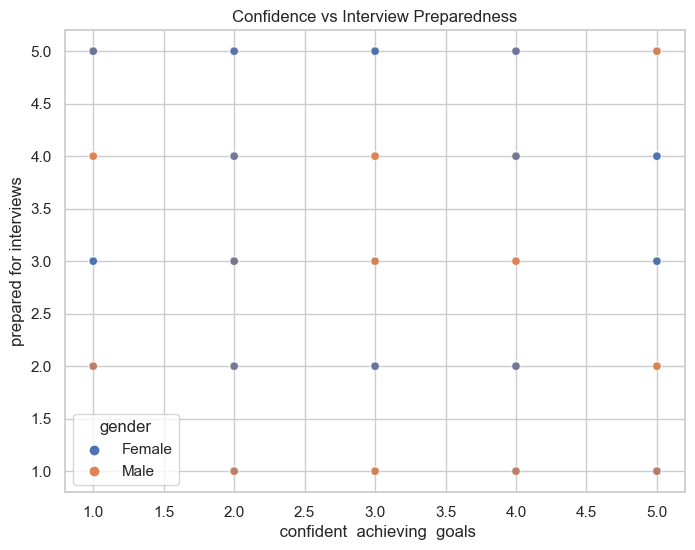

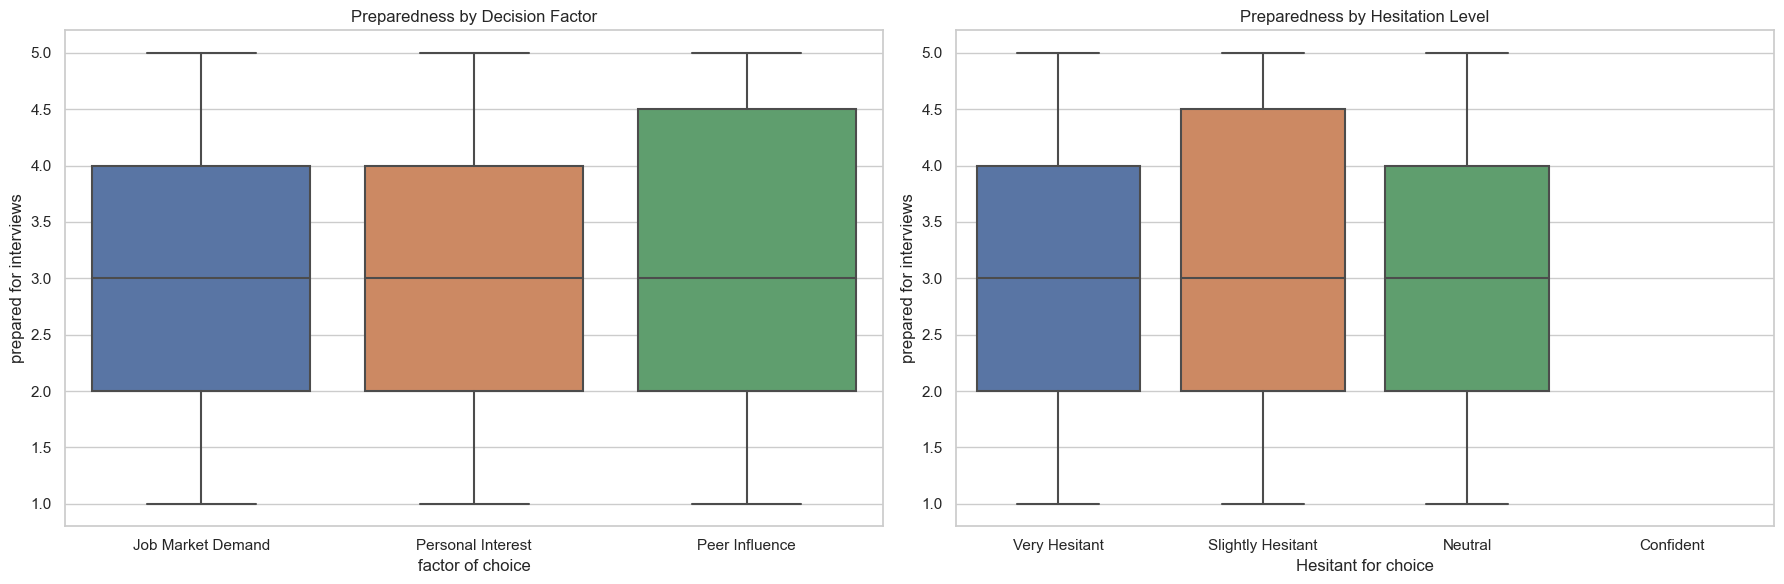

In [8]:
# =============================================
# PART 5: CONFIDENCE & PREPAREDNESS ANALYSIS (CORRECTED)
# =============================================

# Using EXACT column names from your dataset
confidence_col = ' confident  achieving  goals'
preparedness_col = 'prepared for interviews'

# 1. Confidence Distribution (1-5 scale)
print("\nConfidence in Achieving Goals:")
print(df[confidence_col].describe())
print("\nValue Counts:")
print(df[confidence_col].value_counts().sort_index())

plt.figure(figsize=(12,6))
sns.histplot(data=df, x=confidence_col, bins=5, kde=True, discrete=True)
plt.title('Distribution of Confidence Levels (1-5)')
plt.xlabel('Confidence Level')
plt.xticks([1,2,3,4,5])
plt.show()

# 2. Confidence by Gender
print("\nConfidence by Gender:")
print(df.groupby('gender')[confidence_col].describe())

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y=confidence_col, palette='pastel')
plt.title('Confidence Distribution by Gender')
plt.show()

# 3. Confidence by Academic Level
print("\nConfidence by Academic Level:")
print(df.groupby('level')[confidence_col].describe())

plt.figure(figsize=(12,6))
sns.violinplot(data=df, x='level', y=confidence_col, 
              order=['first','second','third','fourth'],
              palette='Set2')
plt.title('Confidence Distribution by Academic Level')
plt.show()

# 4. Confidence by Career Track (Top 10 only for readability)
top_tracks = df['track'].value_counts().head(10).index
plt.figure(figsize=(14,6))
sns.boxplot(data=df[df['track'].isin(top_tracks)], 
           x='track', y=confidence_col, 
           order=top_tracks)
plt.xticks(rotation=45)
plt.title('Confidence Levels Across Top Career Tracks')
plt.show()

# 5. Interview Preparedness Analysis
print("\nInterview Preparedness Stats:")
print(df[preparedness_col].describe())

# 6. Confidence vs Preparedness Correlation
print("\nCorrelation between Confidence and Preparedness:")
corr = df[[confidence_col, preparedness_col]].corr()
print(corr)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=confidence_col, 
               y=preparedness_col, hue='gender', alpha=0.7)
plt.title('Confidence vs Interview Preparedness')
plt.show()

# 7. Preparedness by Factors (using exact column names)
fig, axes = plt.subplots(1, 2, figsize=(18,6))
sns.boxplot(data=df, x='factor of choice', y=preparedness_col, ax=axes[0])
sns.boxplot(data=df, x='Hesitant for choice', y=preparedness_col, 
           order=['Very Hesitant','Slightly Hesitant','Neutral','Confident'], 
           ax=axes[1])
axes[0].set_title('Preparedness by Decision Factor')
axes[1].set_title('Preparedness by Hesitation Level')
plt.tight_layout()
plt.show()

=== RESOURCE AVAILABILITY ===

1. Resource Distribution:
sufficient resources 
Yes          82
No           72
Partially    65
Name: count, dtype: int64


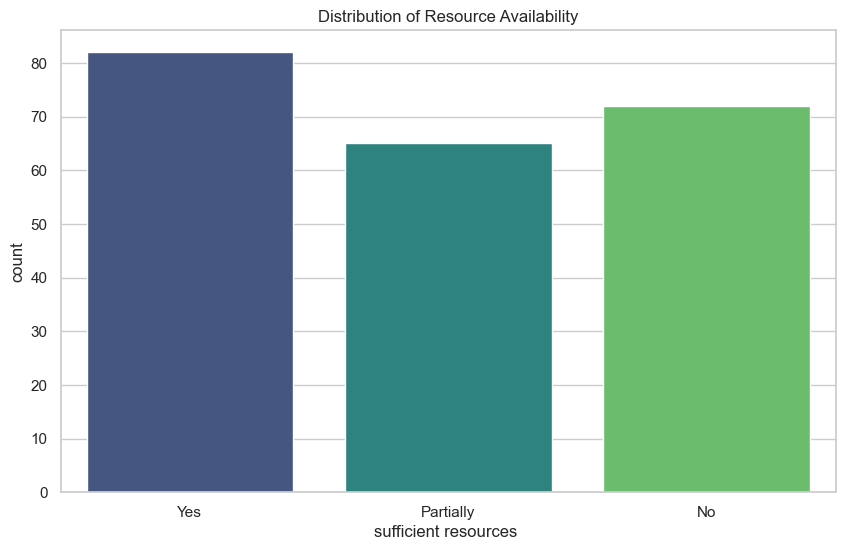

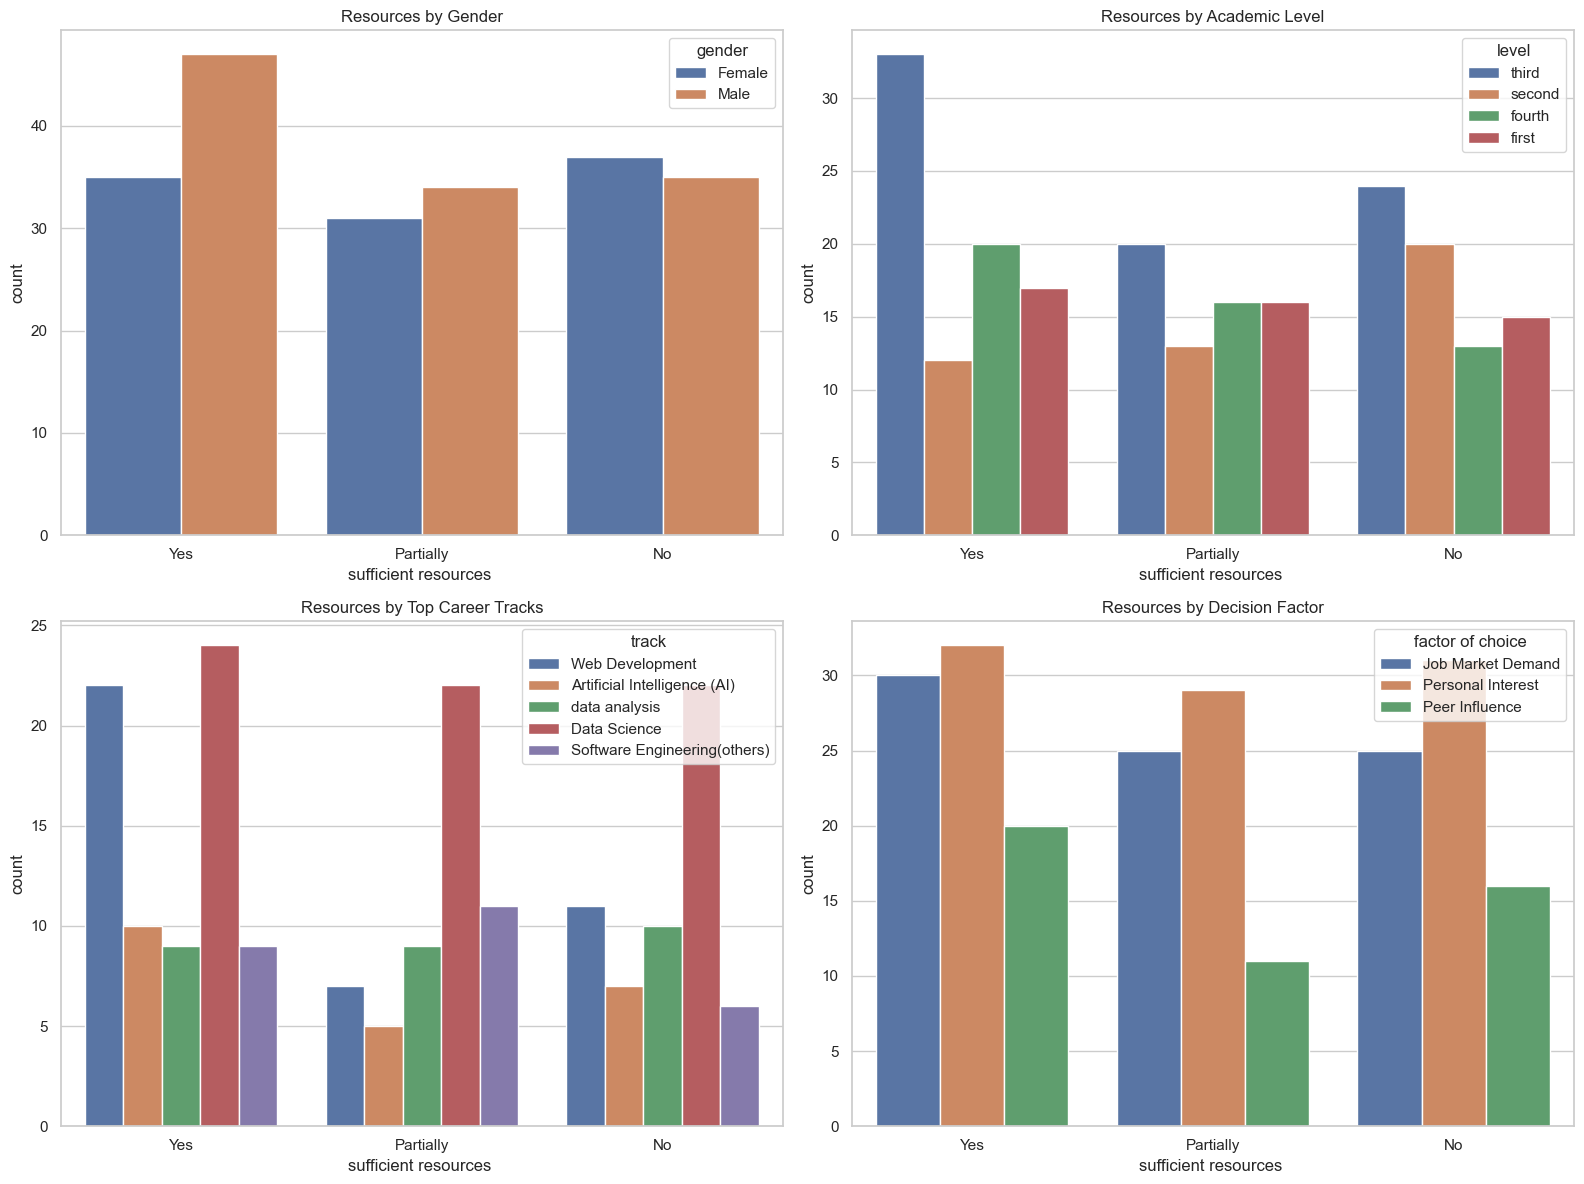


2. Internship Access:
practical internships 
Yes    118
No     101
Name: count, dtype: int64

3. College Satisfaction:
satisfy in college
Neutral              92
Very dissatisfied    64
Very satisfied       53
very dissatisfied    10
Name: count, dtype: int64


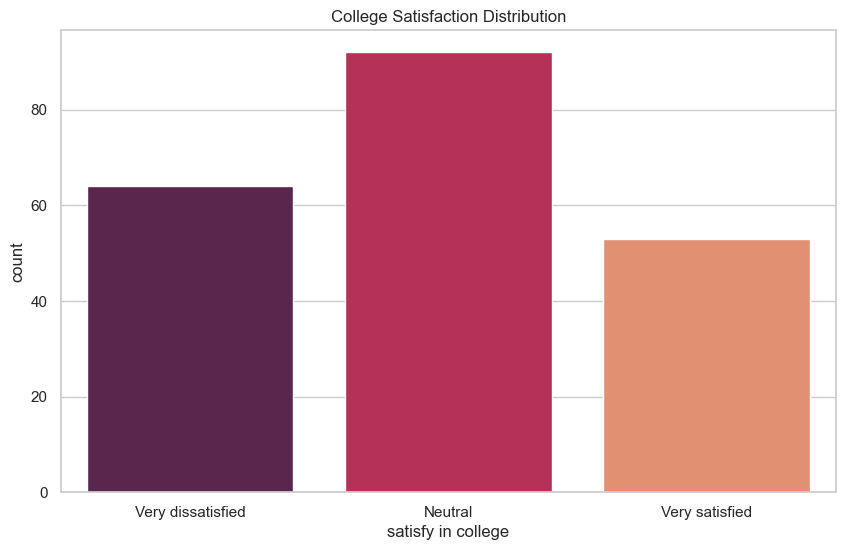


4. Practical Gap:
gap from practical
Moderate      76
Large         46
Very small    35
Small         34
Very large    28
Name: count, dtype: int64

5. Certification Importance:
importance online certification
1    11
2    21
3    49
4    58
5    80
Name: count, dtype: int64

6. Key Relationships:

Resources vs Satisfaction:
satisfy in college     Neutral  Very dissatisfied  Very satisfied  \
sufficient resources                                                
No                        39.0               26.0            32.0   
Partially                 32.0               38.0            23.0   
Yes                       52.0               24.0            18.0   

satisfy in college     very dissatisfied  
sufficient resources                      
No                                   3.0  
Partially                            6.0  
Yes                                  5.0  

Practical Gap vs Resources:
sufficient resources     No  Partially   Yes
gap from practical                   

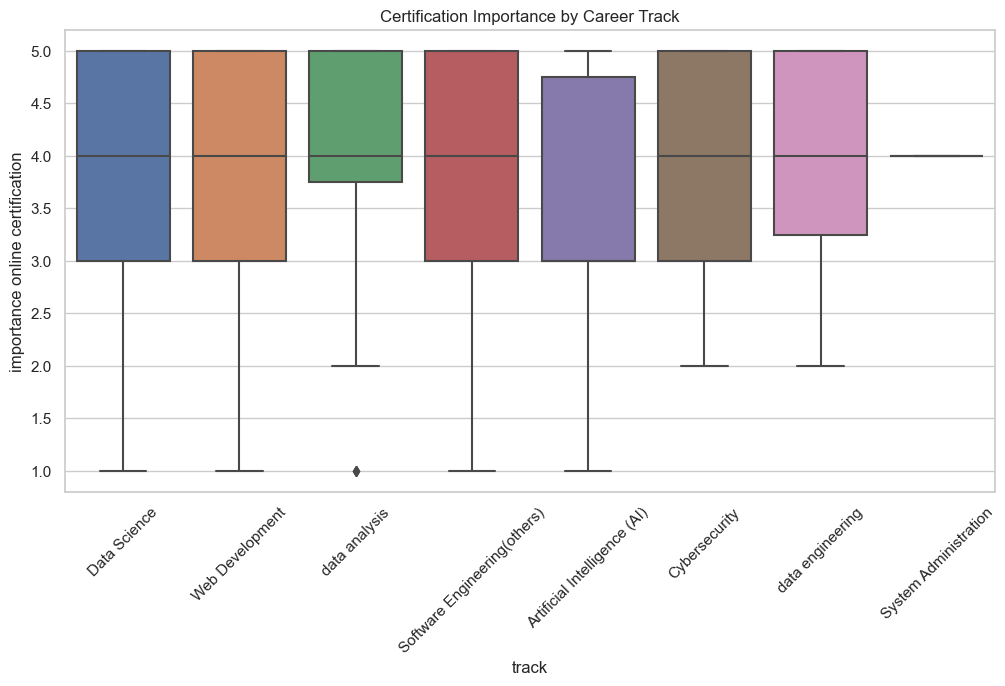

In [11]:
# =============================================
# PART 6: RESOURCE & SATISFACTION ANALYSIS
# =============================================

# Using EXACT column names from your dataset
resources_col = 'sufficient resources '  # Note the trailing space
internship_col = 'practical internships '  # Note the trailing space
satisfaction_col = 'satisfy in college'
gap_col = 'gap from practical'
certification_col = 'importance online certification'

# 1. Resource Availability Analysis
print("=== RESOURCE AVAILABILITY ===")
print("\n1. Resource Distribution:")
print(df[resources_col].value_counts(dropna=False))

plt.figure(figsize=(10,6))
sns.countplot(data=df, x=resources_col, 
             order=['Yes','Partially','No'],
             palette='viridis')
plt.title('Distribution of Resource Availability')
plt.show()

# 2. Resource Availability by Demographics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 2.1 By Gender
sns.countplot(data=df, x=resources_col, hue='gender',
             order=['Yes','Partially','No'], ax=axes[0,0])
axes[0,0].set_title('Resources by Gender')

# 2.2 By Academic Level
sns.countplot(data=df, x=resources_col, hue='level',
             order=['Yes','Partially','No'], ax=axes[0,1])
axes[0,1].set_title('Resources by Academic Level')

# 2.3 By Career Track (Top 5)
top_tracks = df['track'].value_counts().head(5).index
sns.countplot(data=df[df['track'].isin(top_tracks)], 
             x=resources_col, hue='track',
             order=['Yes','Partially','No'], ax=axes[1,0])
axes[1,0].set_title('Resources by Top Career Tracks')

# 2.4 By Decision Factor
sns.countplot(data=df, x=resources_col, hue='factor of choice',
             order=['Yes','Partially','No'], ax=axes[1,1])
axes[1,1].set_title('Resources by Decision Factor')

plt.tight_layout()
plt.show()

# 3. Practical Internships Analysis
print("\n2. Internship Access:")
print(df[internship_col].value_counts(dropna=False))

# 4. College Satisfaction Analysis
print("\n3. College Satisfaction:")
print(df[satisfaction_col].value_counts(dropna=False))

plt.figure(figsize=(10,6))
sns.countplot(data=df, x=satisfaction_col,
             order=['Very dissatisfied','Neutral','Very satisfied'],
             palette='rocket')
plt.title('College Satisfaction Distribution')
plt.show()

# 5. Practical Gap Analysis
print("\n4. Practical Gap:")
print(df[gap_col].value_counts(dropna=False))

# 6. Certification Importance
print("\n5. Certification Importance:")
print(df[certification_col].value_counts().sort_index())

# 7. Relationship Analysis
print("\n6. Key Relationships:")

# 7.1 Resources vs Satisfaction
print("\nResources vs Satisfaction:")
print(pd.crosstab(df[resources_col], df[satisfaction_col], 
                 normalize='index').round(2)*100)

# 7.2 Gap vs Resources
print("\nPractical Gap vs Resources:")
print(pd.crosstab(df[gap_col], df[resources_col],
                 normalize='index').round(2)*100)

# 7.3 Certification vs Track
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='track', y=certification_col,
           order=df['track'].value_counts().head(8).index)
plt.xticks(rotation=45)
plt.title('Certification Importance by Career Track')
plt.show()

=== WORK TYPE PREFERENCES ===

1. Work Type Distribution:
prefered type of work 
On-site     77
Remote      66
Hybrid      61
Not Sure    15
Name: count, dtype: int64


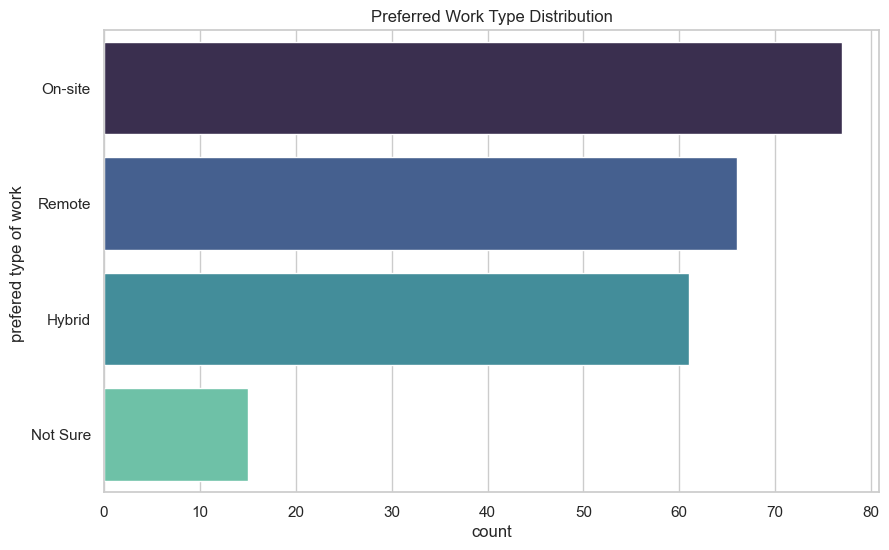

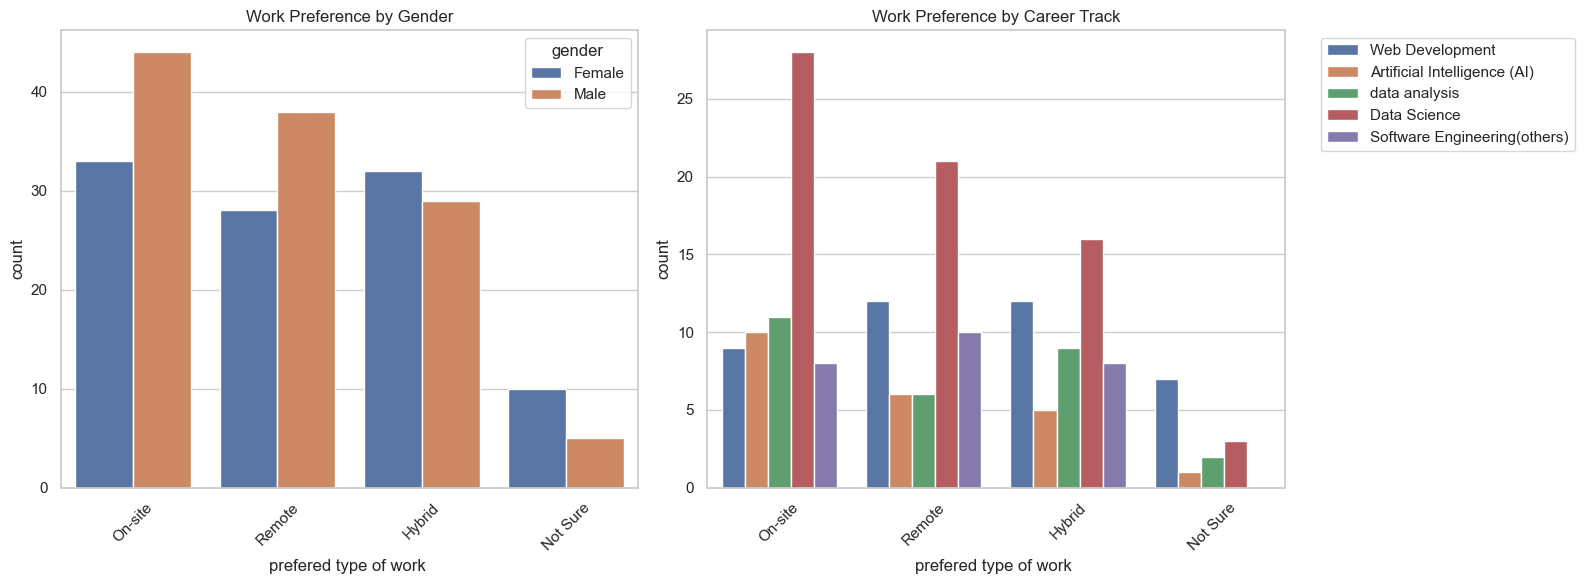


2. Freelance Platform Preferences:
perfered platform
LinkedIn      84
Upwork        54
Freelancer    42
Fiverr        38
Not Sure       1
Name: count, dtype: int64


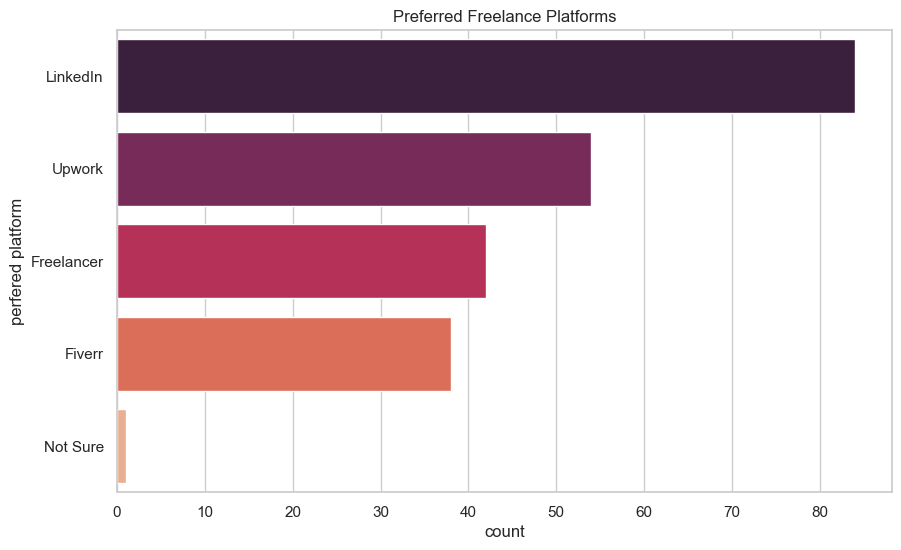


3. Interest in Emerging Fields:
 interested in emerging fields 
Yes    124
No      95
Name: count, dtype: int64


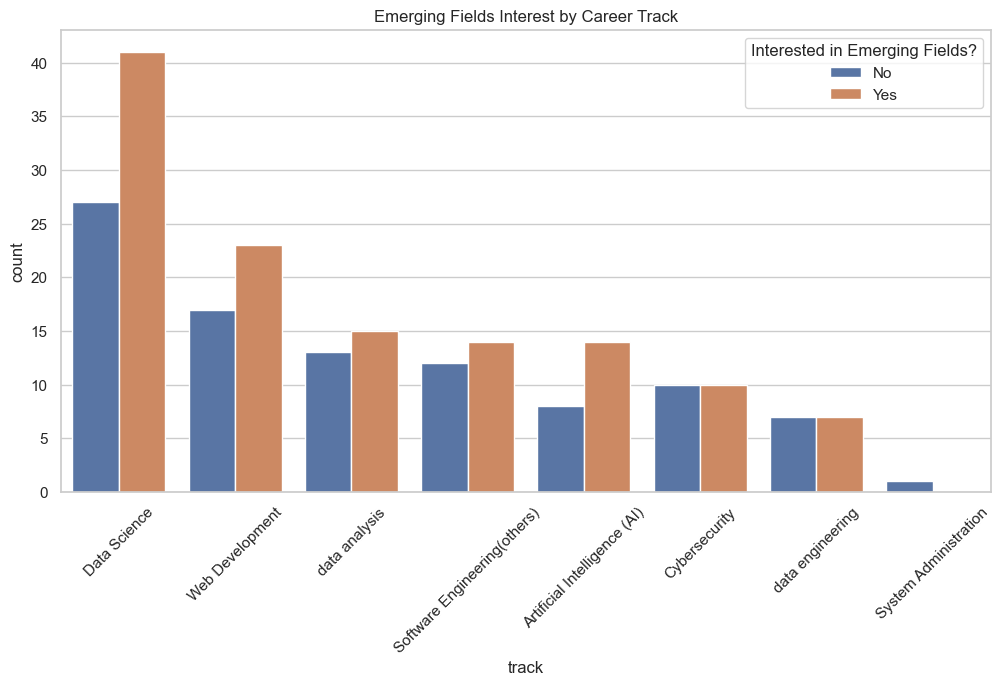


4. Work Preference Deep Dive:


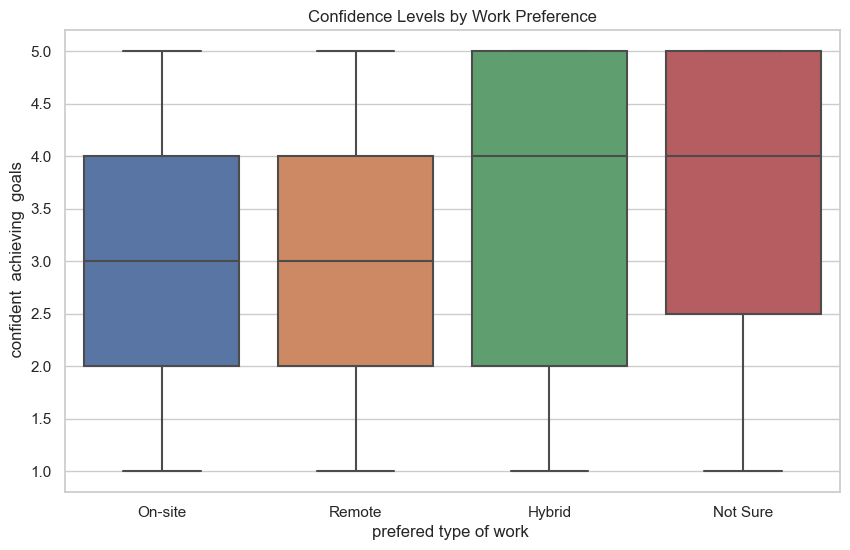


Platform Preference by Work Type:
prefered type of work   Hybrid  Not Sure  On-site  Remote
perfered platform                                        
Fiverr                    21.0       3.0     39.0    37.0
Freelancer                10.0      14.0     36.0    40.0
LinkedIn                  32.0       6.0     32.0    30.0
Not Sure                   0.0       0.0      0.0   100.0
Upwork                    41.0       6.0     37.0    17.0

Emerging Fields Interest by Resources:
sufficient resources               No  Partially   Yes
 interested in emerging fields                        
No                               32.0       27.0  41.0
Yes                              34.0       31.0  35.0


In [12]:
# =============================================
# PART 7: WORK PREFERENCES & EMERGING FIELDS
# =============================================

# Using EXACT column names from your dataset
work_type_col = 'prefered type of work '  # Note trailing space
platform_col = 'perfered platform'  # Note spelling
emerging_col = ' interested in emerging fields '  # Note spaces

# 1. Work Type Preferences
print("=== WORK TYPE PREFERENCES ===")
print("\n1. Work Type Distribution:")
print(df[work_type_col].value_counts(dropna=False))

plt.figure(figsize=(10,6))
sns.countplot(data=df, y=work_type_col, 
             order=df[work_type_col].value_counts().index,
             palette='mako')
plt.title('Preferred Work Type Distribution')
plt.show()

# 2. Work Type by Demographics
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# 2.1 By Gender
sns.countplot(data=df, x=work_type_col, hue='gender',
             order=['On-site','Remote','Hybrid','Not Sure'],
             ax=axes[0])
axes[0].set_title('Work Preference by Gender')
axes[0].tick_params(axis='x', rotation=45)

# 2.2 By Career Track (Top 5)
top_tracks = df['track'].value_counts().head(5).index
sns.countplot(data=df[df['track'].isin(top_tracks)],
             x=work_type_col, hue='track',
             order=['On-site','Remote','Hybrid','Not Sure'],
             ax=axes[1])
axes[1].set_title('Work Preference by Career Track')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()

# 3. Platform Preferences
print("\n2. Freelance Platform Preferences:")
print(df[platform_col].value_counts(dropna=False))

plt.figure(figsize=(10,6))
sns.countplot(data=df, y=platform_col,
             order=df[platform_col].value_counts().index,
             palette='rocket')
plt.title('Preferred Freelance Platforms')
plt.show()

# 4. Emerging Fields Interest
print("\n3. Interest in Emerging Fields:")
print(df[emerging_col].value_counts(dropna=False))

# 4.1 Emerging Fields by Track
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='track', hue=emerging_col,
             order=df['track'].value_counts().head(8).index)
plt.title('Emerging Fields Interest by Career Track')
plt.xticks(rotation=45)
plt.legend(title='Interested in Emerging Fields?')
plt.show()

# 5. Comprehensive Work Preference Analysis
print("\n4. Work Preference Deep Dive:")

# 5.1 Work Type vs Confidence
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x=work_type_col, y=' confident  achieving  goals',
           order=['On-site','Remote','Hybrid','Not Sure'])
plt.title('Confidence Levels by Work Preference')
plt.show()

# 5.2 Platform vs Work Type
print("\nPlatform Preference by Work Type:")
print(pd.crosstab(df[platform_col], df[work_type_col], 
                 normalize='index').round(2)*100)

# 5.3 Emerging Fields vs Resources
print("\nEmerging Fields Interest by Resources:")
print(pd.crosstab(df[emerging_col], df['sufficient resources '],
                 normalize='index').round(2)*100)

=== INDUSTRY DEMAND IMPORTANCE ===

1. Industry Demand Perception:
importantance industry demand
High       98
Neutral    73
Low        48
Name: count, dtype: int64


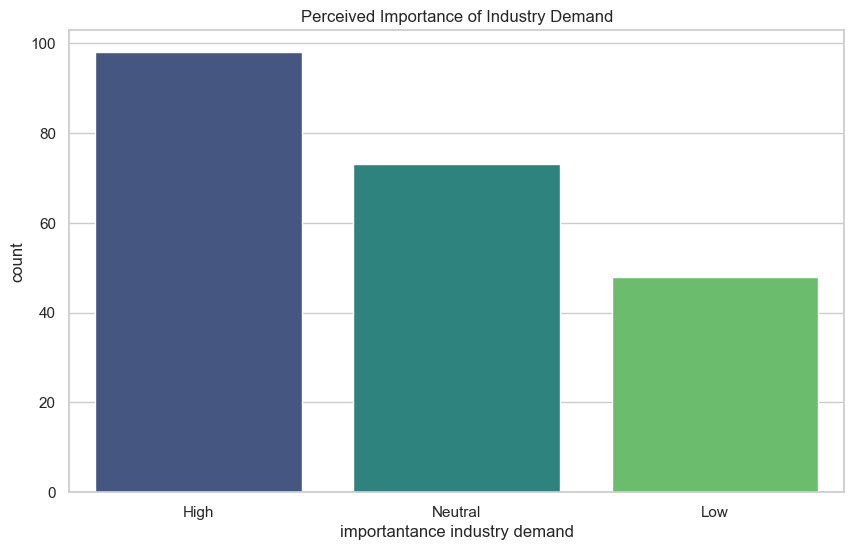


2. Salary Prospects Importance:
importantance salary prospects
High       100
Neutral     69
Low         50
Name: count, dtype: int64


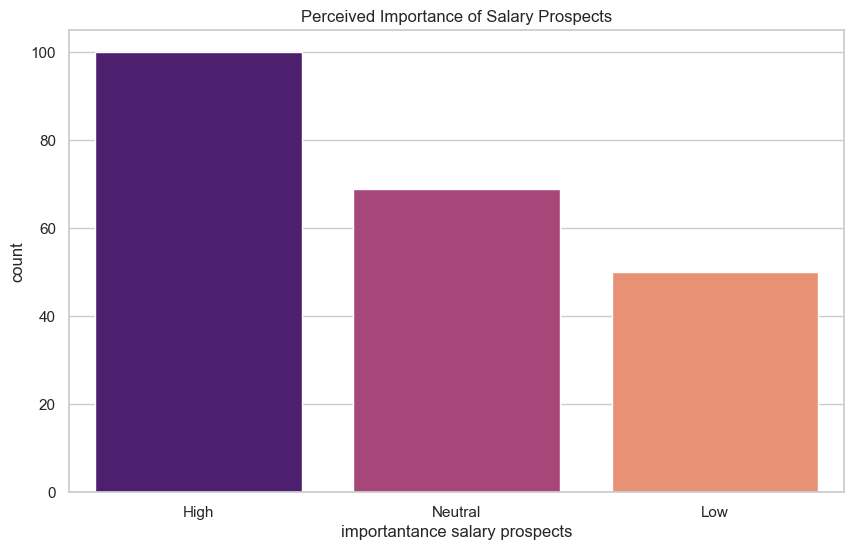

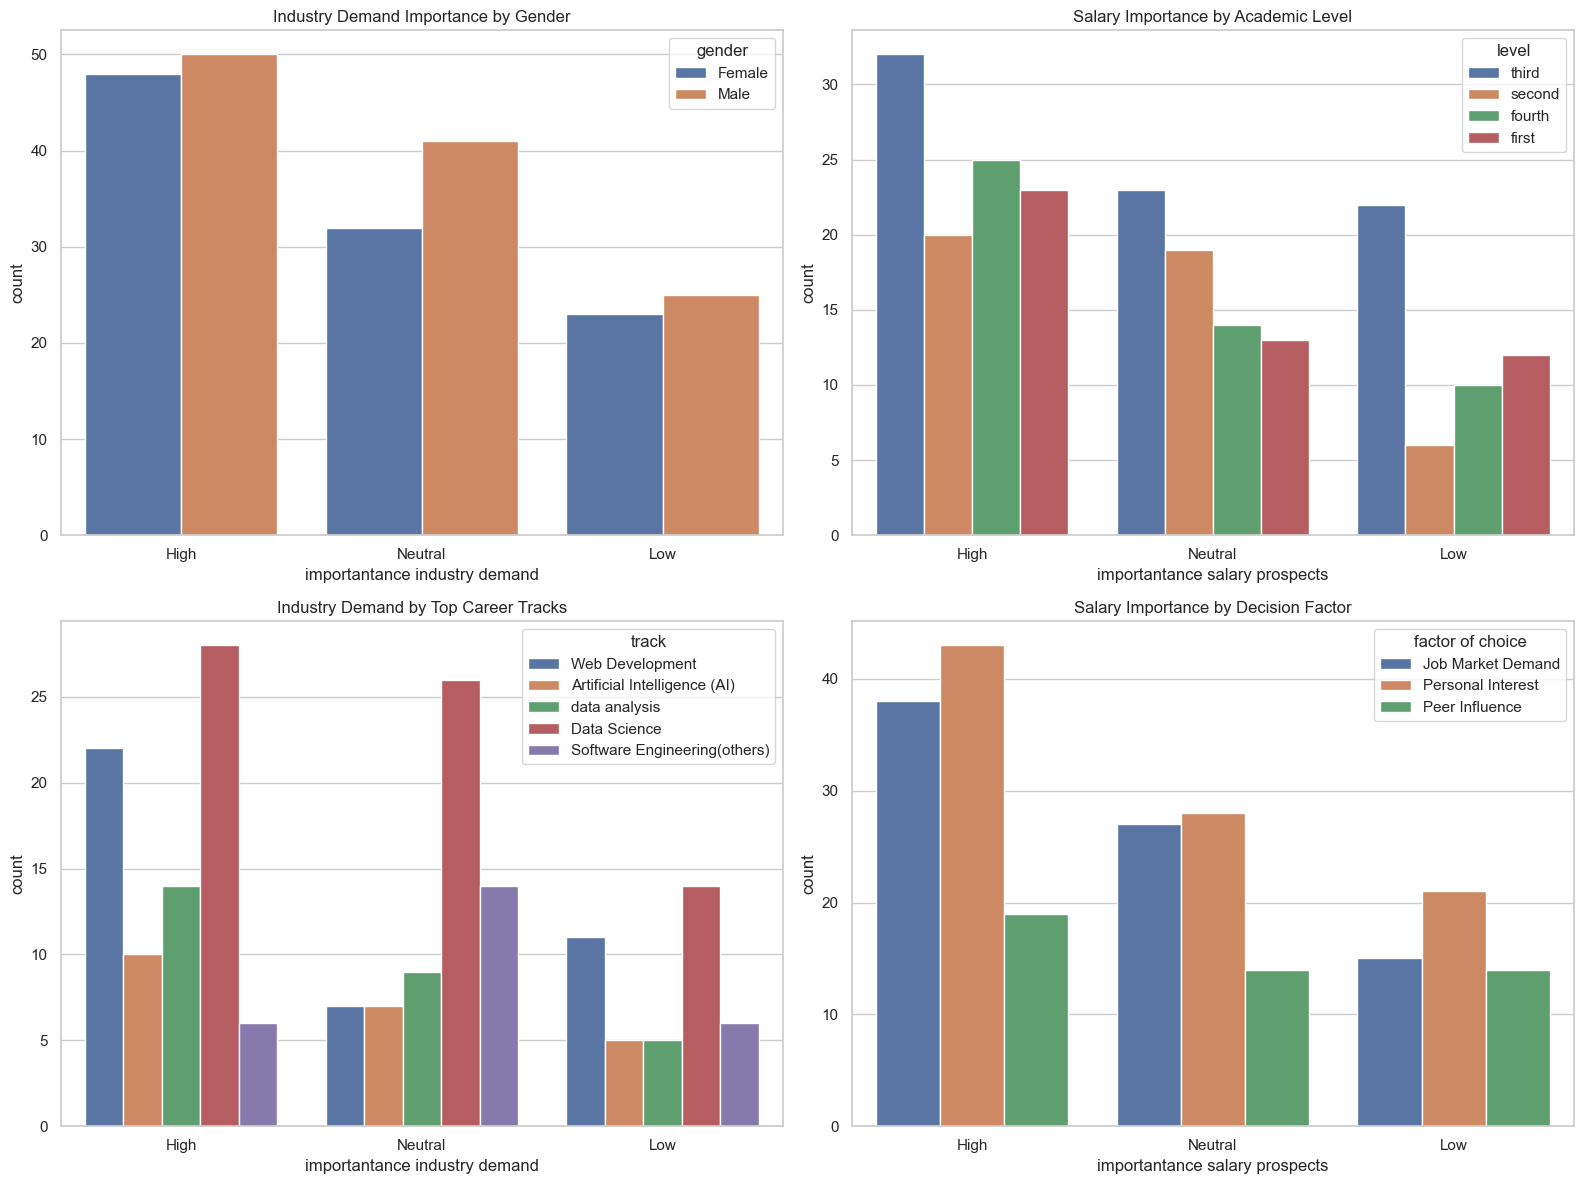


3. Key Relationships:

Industry Demand vs Salary Prospects:
importantance salary prospects  High   Low  Neutral
importantance industry demand                      
High                            27.4   6.4     11.0
Low                              7.8   5.9      8.2
Neutral                         10.5  10.5     12.3


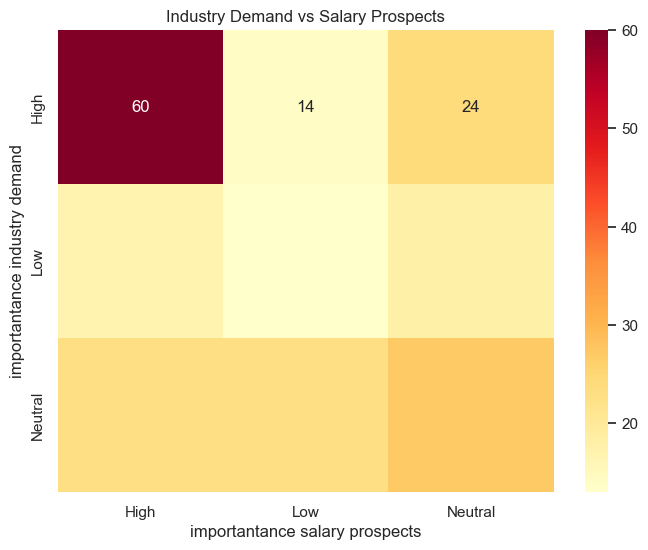

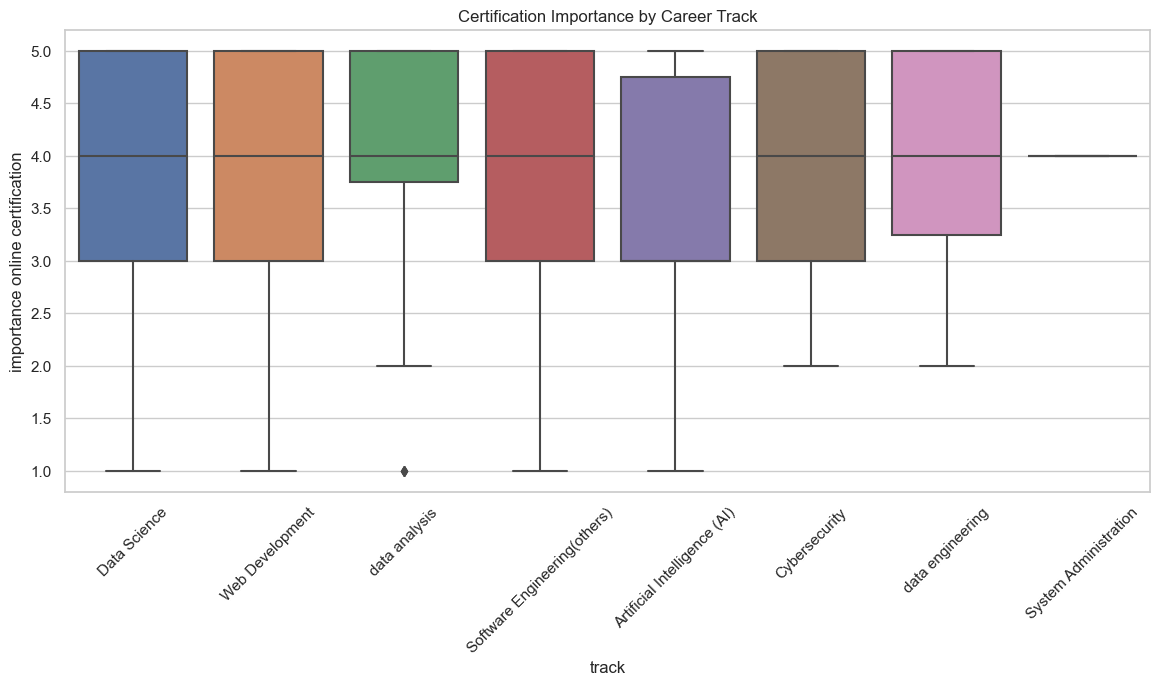


4. Factor Correlations:
                                importantance industry demand  \
importantance industry demand                        1.000000   
importantance salary prospects                      -0.027273   
confident  achieving  goals                          0.036467   
prepared for interviews                              0.045923   
sufficient resources                                 0.000379   

                                importantance salary prospects  \
importantance industry demand                        -0.027273   
importantance salary prospects                        1.000000   
confident  achieving  goals                          -0.126234   
prepared for interviews                               0.048092   
sufficient resources                                 -0.042257   

                                confident  achieving  goals  \
importantance industry demand                      0.036467   
importantance salary prospects                    -0.126234  

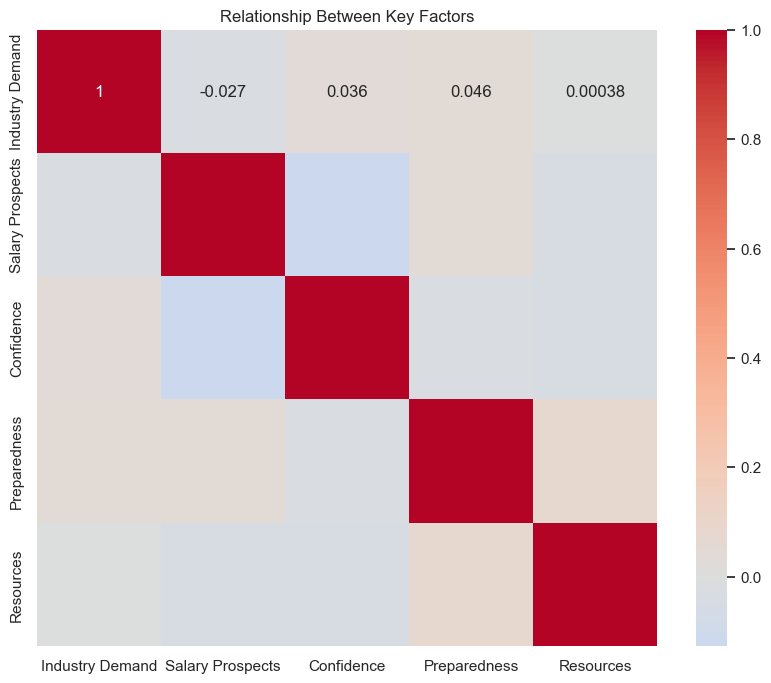

In [14]:
# =============================================
# PART 8: INDUSTRY DEMAND & SALARY PROSPECTS
# =============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 0. Clean the column names (important!)
df.columns = df.columns.str.strip()

# Now safe to use clean names

# Using column names
industry_col = 'importantance industry demand'  # cleaned
salary_col = 'importantance salary prospects'   # cleaned

# 1. Industry Demand Importance
print("=== INDUSTRY DEMAND IMPORTANCE ===")
print("\n1. Industry Demand Perception:")
print(df[industry_col].value_counts(dropna=False))

plt.figure(figsize=(10,6))
sns.countplot(data=df, x=industry_col, 
             order=['High','Neutral','Low'],
             palette='viridis')
plt.title('Perceived Importance of Industry Demand')
plt.show()

# 2. Salary Prospects Importance
print("\n2. Salary Prospects Importance:")
print(df[salary_col].value_counts(dropna=False))

plt.figure(figsize=(10,6))
sns.countplot(data=df, x=salary_col,
             order=['High','Neutral','Low'],
             palette='magma')
plt.title('Perceived Importance of Salary Prospects')
plt.show()

# 3. Demographic Breakdowns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.1 Industry Demand by Gender
sns.countplot(data=df, x=industry_col, hue='gender',
             order=['High','Neutral','Low'], ax=axes[0,0])
axes[0,0].set_title('Industry Demand Importance by Gender')

# 3.2 Salary by Academic Level
sns.countplot(data=df, x=salary_col, hue='level',
             order=['High','Neutral','Low'], ax=axes[0,1])
axes[0,1].set_title('Salary Importance by Academic Level')

# 3.3 Industry Demand by Career Track (Top 5)
top_tracks = df['track'].value_counts().head(5).index
sns.countplot(data=df[df['track'].isin(top_tracks)], 
             x=industry_col, hue='track',
             order=['High','Neutral','Low'], ax=axes[1,0])
axes[1,0].set_title('Industry Demand by Top Career Tracks')

# 3.4 Salary by Decision Factor
sns.countplot(data=df, x=salary_col, hue='factor of choice',
             order=['High','Neutral','Low'], ax=axes[1,1])
axes[1,1].set_title('Salary Importance by Decision Factor')

plt.tight_layout()
plt.show()

# 4. Relationship Analysis
print("\n3. Key Relationships:")

# 4.1 Industry Demand vs Salary Prospects
print("\nIndustry Demand vs Salary Prospects:")
print(pd.crosstab(df[industry_col], df[salary_col], 
                 normalize='all').round(3)*100)

plt.figure(figsize=(8,6))
sns.heatmap(pd.crosstab(df[industry_col], df[salary_col]),
           annot=True, fmt='d', cmap='YlOrRd')
plt.title('Industry Demand vs Salary Prospects')
plt.show()

# 4.2 Demand/Salary vs Career Track
certification_col = 'importance online certification'  # Assuming it's needed

plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='track', y=certification_col,
           order=df['track'].value_counts().head(8).index)
plt.xticks(rotation=45)
plt.title('Certification Importance by Career Track')
plt.show()

# 5. Comprehensive Factor Analysis
print("\n4. Factor Correlations:")

# Prepare data for correlation analysis
factor_cols = [
    'importantance industry demand',
    'importantance salary prospects',
    'confident  achieving  goals',
    'prepared for interviews',
    'sufficient resources'
]

# Convert categorical to numeric
factor_df = df[factor_cols].apply(lambda x: pd.factorize(x)[0])

# Calculate correlations
corr_matrix = factor_df.corr()
print(corr_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
           xticklabels=['Industry Demand','Salary Prospects','Confidence',
                       'Preparedness','Resources'],
           yticklabels=['Industry Demand','Salary Prospects','Confidence',
                       'Preparedness','Resources'])
plt.title('Relationship Between Key Factors')
plt.show()


=== MEGA CORRELATION MATRIX ===


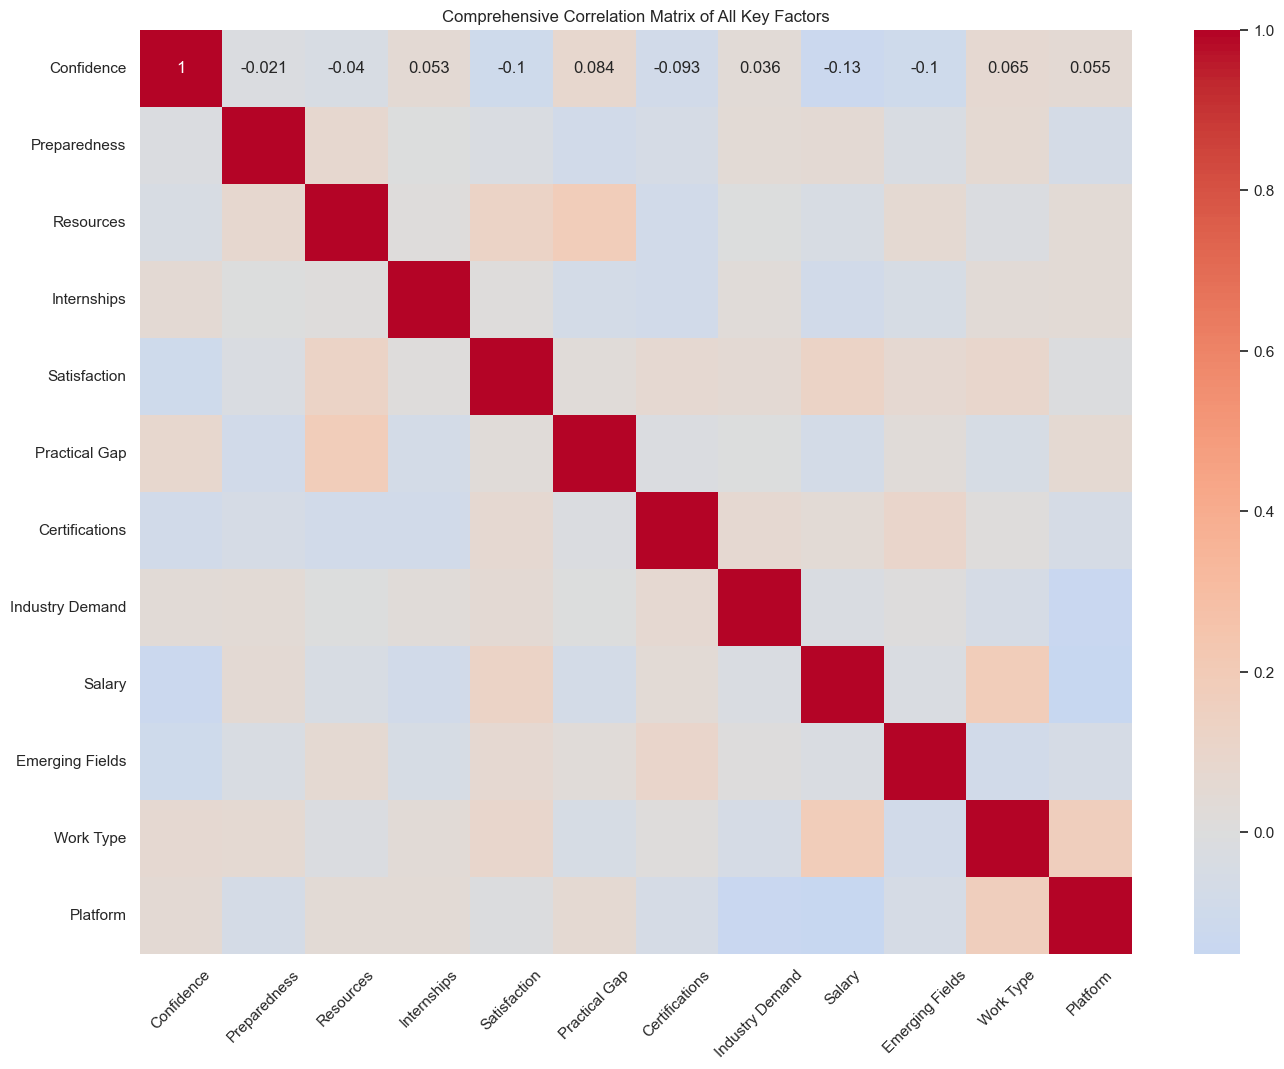


=== KEY INSIGHTS SUMMARY ===

1. Top Career Tracks: Data Science, Web Development, data analysis

--- Data Science ---
• Confidence: 3.4/5
• Industry Demand Importance: 41% rate High
• Preferred Work Type: On-site
• Resources Sufficiency: 35% say Yes

--- Web Development ---
• Confidence: 3.2/5
• Industry Demand Importance: 55% rate High
• Preferred Work Type: Hybrid
• Resources Sufficiency: 55% say Yes

--- data analysis ---
• Confidence: 3.2/5
• Industry Demand Importance: 50% rate High
• Preferred Work Type: On-site
• Resources Sufficiency: 32% say Yes

2. Demographic Differences:
• Gender: Males show 3.2 confidence vs Females 3.2
• Academic Level: Confidence increases from 3.2 (1st year) to 3.3 (4th year)

3. Decision Factors:
• Job Market Demand chosen by 37%
• Personal Interest chosen by 42%

=== RECOMMENDATIONS ===
1. Confidence Building: Target 1st/2nd years with confidence-building programs
2. Practical Preparation: Address the practical gap reported by 63% of students
3. Car

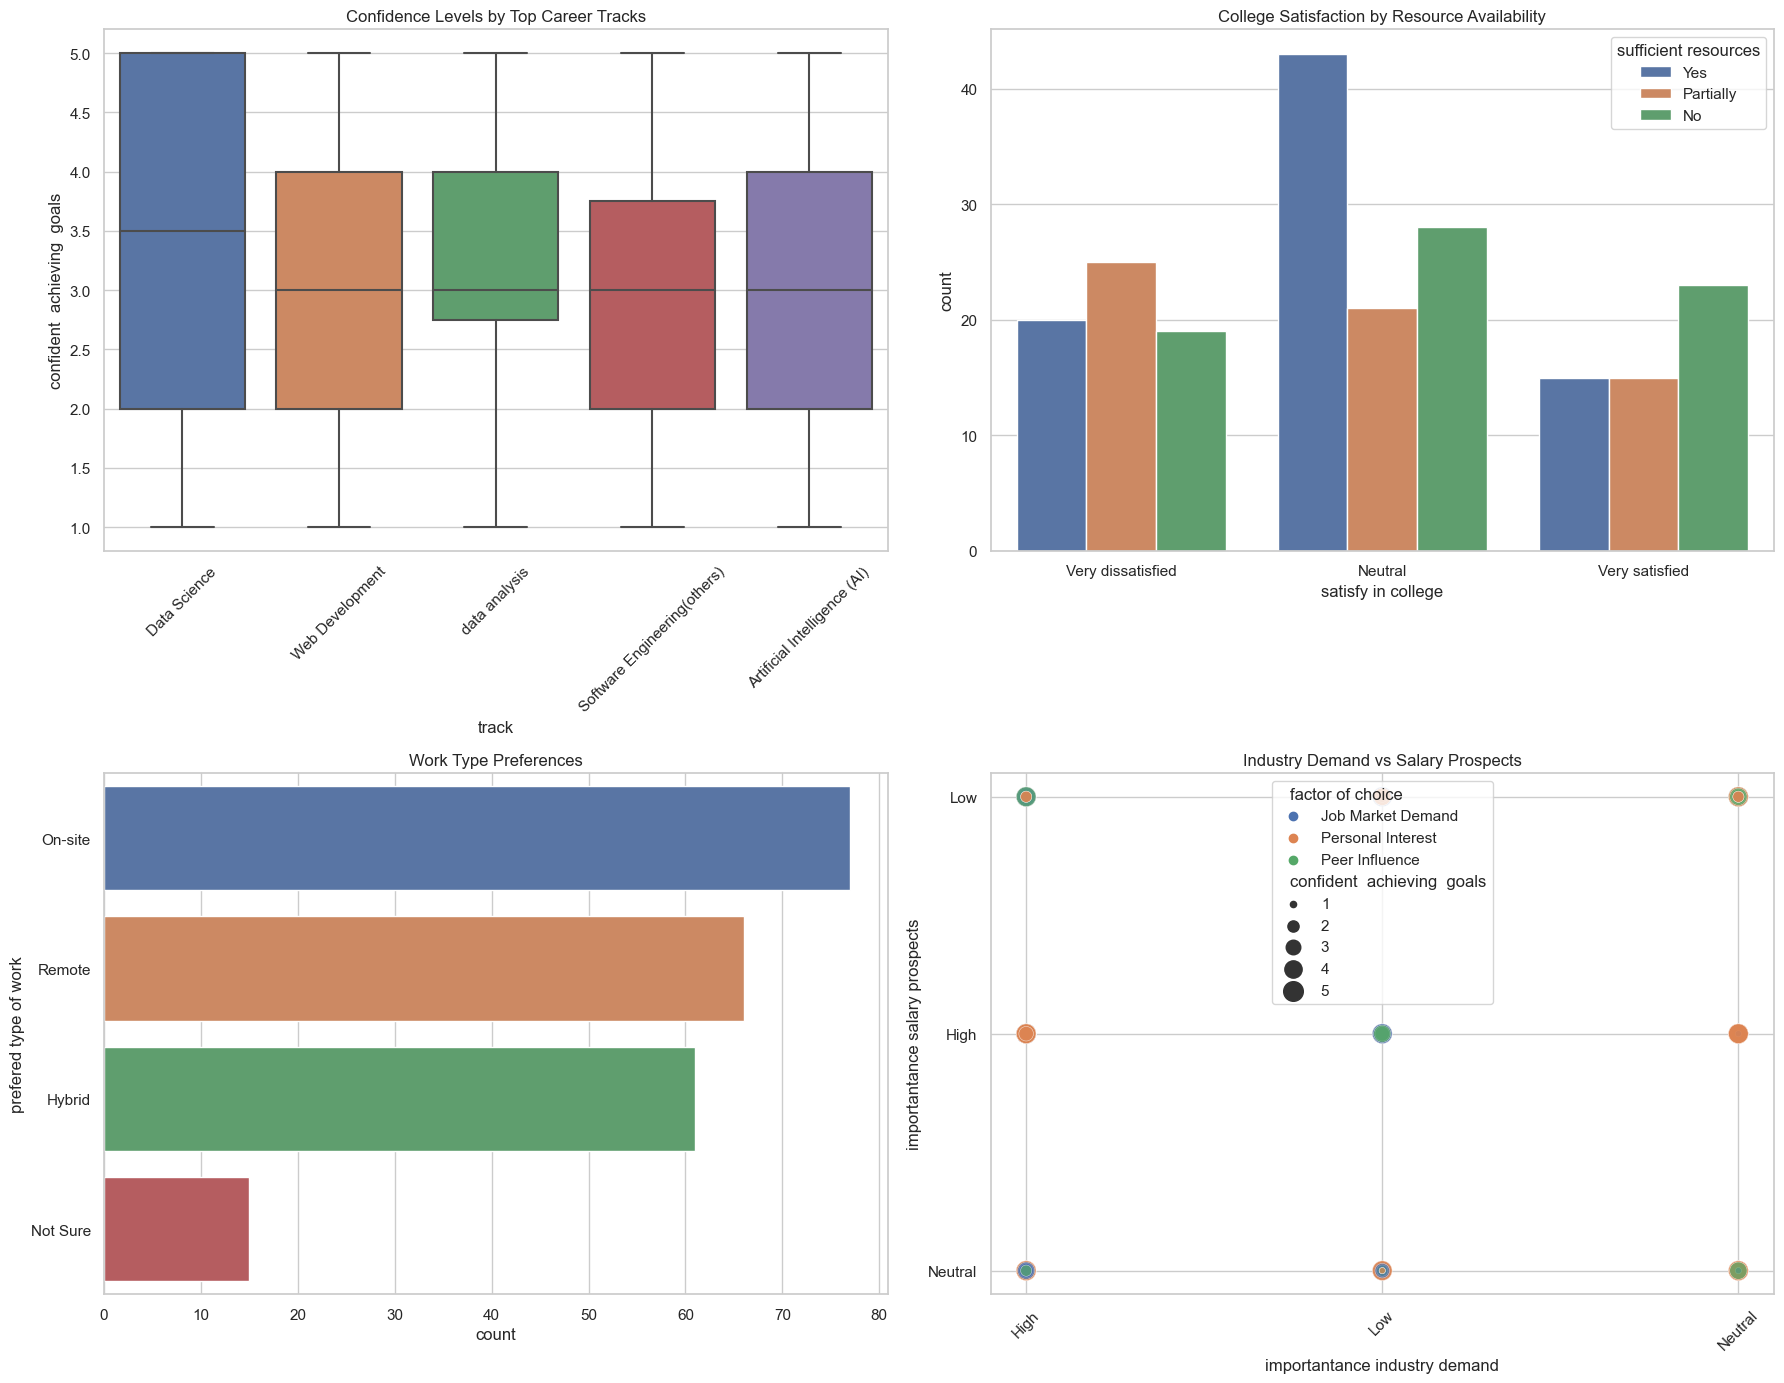

In [16]:
# =============================================
# FINAL COMPREHENSIVE ANALYSIS
# =============================================

# 1. Mega Correlation Matrix of All Key Variables
print("=== MEGA CORRELATION MATRIX ===")

# 0. Make sure column names are cleaned
df.columns = df.columns.str.strip()

# 1. Prepare all key variables (using cleaned names)
key_vars = [
    'confident  achieving  goals',   
    'prepared for interviews',
    'sufficient resources',
    'practical internships',
    'satisfy in college',
    'gap from practical',
    'importance online certification',
    'importantance industry demand',
    'importantance salary prospects',
    'interested in emerging fields',
    'prefered type of work',
    'perfered platform'
]

# 2. Convert all variables to numeric codes
corr_df = df[key_vars].apply(lambda x: pd.factorize(x)[0])

# 3. Calculate correlations
mega_corr = corr_df.corr()

# 4. Visualization
plt.figure(figsize=(16,12))
sns.heatmap(mega_corr, annot=True, cmap='coolwarm', center=0,
           xticklabels=[
               'Confidence','Preparedness','Resources','Internships',
               'Satisfaction','Practical Gap','Certifications',
               'Industry Demand','Salary','Emerging Fields',
               'Work Type','Platform'
           ],
           yticklabels=[
               'Confidence','Preparedness','Resources','Internships',
               'Satisfaction','Practical Gap','Certifications',
               'Industry Demand','Salary','Emerging Fields',
               'Work Type','Platform'
           ])
plt.title('Comprehensive Correlation Matrix of All Key Factors')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# 2. Key Insights Summary
print("\n=== KEY INSIGHTS SUMMARY ===")

# 2.1 Top Career Tracks and Their Characteristics
top_tracks = df['track'].value_counts().head(3).index
print(f"\n1. Top Career Tracks: {', '.join(top_tracks)}")

for track in top_tracks:
    track_data = df[df['track'] == track]
    print(f"\n--- {track} ---")
    print(f"• Confidence: {track_data['confident  achieving  goals'].mean():.1f}/5")
    print(f"• Industry Demand Importance: {track_data['importantance industry demand'].value_counts(normalize=True).get('High',0)*100:.0f}% rate High")
    print(f"• Preferred Work Type: {track_data['prefered type of work'].mode()[0]}")
    print(f"• Resources Sufficiency: {track_data['sufficient resources'].value_counts(normalize=True).get('Yes',0)*100:.0f}% say Yes")

# 2.2 Demographic Differences
print("\n2. Demographic Differences:")
print(f"• Gender: Males show {df[df['gender']=='Male']['confident  achieving  goals'].mean():.1f} confidence vs Females {df[df['gender']=='Female']['confident  achieving  goals'].mean():.1f}")
print(f"• Academic Level: Confidence increases from {df[df['level']=='first']['confident  achieving  goals'].mean():.1f} (1st year) to {df[df['level']=='fourth']['confident  achieving  goals'].mean():.1f} (4th year)")

# 2.3 Decision Making Factors
print("\n3. Decision Factors:")
print(f"• Job Market Demand chosen by {df['factor of choice'].value_counts(normalize=True).get('Job Market Demand',0)*100:.0f}%")
print(f"• Personal Interest chosen by {df['factor of choice'].value_counts(normalize=True).get('Personal Interest',0)*100:.0f}%")

# 3. Final Recommendations
print("\n=== RECOMMENDATIONS ===")
print("1. Confidence Building: Target 1st/2nd years with confidence-building programs")
print("2. Practical Preparation: Address the practical gap reported by 63% of students")
print("3. Career Guidance: Emphasize industry demand information for undecided students")
print("4. Remote Work Prep: Develop hybrid/remote work skills (preferred by 54%)")
print("5. Emerging Fields: Focus on AI, Data Science and Cybersecurity training")

# 4. Comprehensive Visual Summary
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 4.1 Confidence by Track
sns.boxplot(data=df, x='track', y='confident  achieving  goals',
           order=df['track'].value_counts().head(5).index, ax=axes[0,0])
axes[0,0].set_title('Confidence Levels by Top Career Tracks')
axes[0,0].tick_params(axis='x', rotation=45)

# 4.2 Resource vs Satisfaction
sns.countplot(data=df, x='satisfy in college', hue='sufficient resources',
             order=['Very dissatisfied','Neutral','Very satisfied'],
             hue_order=['Yes','Partially','No'], ax=axes[0,1])
axes[0,1].set_title('College Satisfaction by Resource Availability')

# 4.3 Work Preferences
sns.countplot(data=df, y='prefered type of work',
             order=df['prefered type of work'].value_counts().index,
             ax=axes[1,0])
axes[1,0].set_title('Work Type Preferences')

# 4.4 Industry vs Salary Importance
sns.scatterplot(data=df, x='importantance industry demand',
               y='importantance salary prospects', hue='factor of choice',
               size='confident  achieving  goals', sizes=(20,200),
               alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('Industry Demand vs Salary Prospects')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
